In [1]:
import accelforge as af
from scheduling.scheduler import *
from af_wrapper import *
import numpy as np


def run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = None,
    total_latency_grid = None,
    actions_grid = None,
    memory_name = None,
    shared_memory_info = None,
):
    schedule, min_latency = best_schedule(
        einsums,
        compute_units,
        shared_memory_info,
        data_dependencies,
        latency_per_component_grid,
        total_latency_grid,
        actions_grid,
        memory_name
    )
    return schedule, min_latency


In [2]:
arch = "arch/tpu-v4i/full.yaml"
m2_workload = "workload/mix-mem-compute-intensive/full.yaml"

In [3]:
data_dependencies = {
    # left (matmuls)
    "AB": [],
    "ABC": ["AB"],
    "ABCD": ["ABC"],

    # right (matvecs)
    "Y0": [],
    "Y1": ["Y0"],
    "Y2": ["Y1"],

    # join
    "OUT": ["ABCD", "Y2"],
}

compute_units = ['1', '2', '3', '4']
einsums = data_dependencies.keys()
memory_name = "MainMemory"
shared_mem_info = {'GlobalBuffer' : [(50, 25, 15, 10), (25, 25, 25, 25)]}

In [4]:
from arch.arch_utils import *

arch_pairings = generate_architecture_pairings(compute_units, shared_mem_info)


In [5]:
# RUN TO GENERATE ACCELFORGE VALUES FOR SHARED MEMORY-AWARE SCHEDULING.
# To skip recomputation when running with fresh kernel, comment out
# this cell and use the below assignments instead.

(grid_lats, grid_mems, grid_maps) = af_memoizable_grid_mem(
     einsums, 
     arch_pairings,
     lambda einsum: "workload/mix-mem-compute-intensive/"+einsum+".yaml",
     "arch/tpu-v4i/"
)

Getting cell 1 of 49 : AB ('1', ('GlobalBuffer', 25))


Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]
Generating jobs:   0%|          | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit1 Einsum AB: 0it [00:00, ?it/s]

Generating pmapping templates for compute MAC1 Einsum AB: 0it [00:00, ?it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 3it [00:00, 20.89it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 6it [00:00, 18.69it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 8it [00:00, 15.57it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 10it [00:00, 16.09it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 12it [00:00, 15.74it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 14it [00:00, 16.00it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 16it [00:01, 14.92it/s]
Generating pmapping templates for compute MAC1 Einsum AB: 19it [00:01, 18.20it/s]
Genera

Einsum AB has 22 pmapping jobs:
	0	[B in MainMemory] [AB in MainMemory] [A in MainMemory] T-m  T-n  [A in LocalBuffer1] T-k  [AB in LocalBuffer1] T-n  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes AB
	1	[B in MainMemory] [AB in MainMemory] [A in MainMemory] T-k  T-m  [AB in LocalBuffer1] T-n  [A in LocalBuffer1] T-k  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes AB
	2	[B in MainMemory] [AB in MainMemory] [A in MainMemory] T-m  T-n  [A in GlobalBuffer] T-k  [AB in LocalBuffer1] T-n  [A in LocalBuffer1] T-k  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes AB
	3	[B in MainMemory] [AB in MainMemory] [A in MainMemory] T-k  T-m  [AB in GlobalBuffer] T-n  [A in LocalBuffer1] T-k  [AB in LocalBuffer1] T-n  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes AB
	4	[B in MainMemory] [AB in MainMemory] [A in MainMemory] T-k  T-n  [B in GlobalBuffer] T-m  [A in LocalBuffer1] T-k  [AB in LocalBuffer1] T-n  S

Compressing pmappings: 100%|██████████| 1/1 [00:00<00:00, 74.48it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=1.22e-07
Final clean join.


Dirty pruning pmappings: 100%|██████████| 1/1 [00:00<00:00, 322.76it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|██████████| 1/1 [00:00<00:00, 2064.13it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [6]:
grid_lats

{(('1', ('GlobalBuffer', 25)), 'AB'): {'MAC1': np.float32(1.2190476e-07),
  'LocalBuffer1': np.int64(0),
  'GlobalBuffer': np.float32(8e-08),
  'MainMemory': np.float32(1.0673616e-07),
  'Register1': np.int64(0)},
 (('1', ('GlobalBuffer', 25)), 'ABC'): {'MAC1': np.float32(1.2190476e-07),
  'LocalBuffer1': np.int64(0),
  'GlobalBuffer': np.float32(8e-08),
  'MainMemory': np.float32(1.0673616e-07),
  'Register1': np.int64(0)},
 (('1', ('GlobalBuffer', 25)), 'ABCD'): {'MAC1': np.float32(1.2190476e-07),
  'LocalBuffer1': np.int64(0),
  'GlobalBuffer': np.float32(8e-08),
  'MainMemory': np.float32(1.0673616e-07),
  'Register1': np.int64(0)},
 (('1', ('GlobalBuffer', 25)), 'Y0'): {'MAC1': np.float32(1.2190476e-07),
  'LocalBuffer1': np.int64(0),
  'GlobalBuffer': np.float32(3.2125e-08),
  'MainMemory': np.float32(5.3576546e-08),
  'Register1': np.int64(0)},
 (('1', ('GlobalBuffer', 25)), 'Y1'): {'MAC1': np.float32(1.2190476e-07),
  'LocalBuffer1': np.int64(0),
  'GlobalBuffer': np.float32(3.

In [7]:
grid_mems

{(('1', ('GlobalBuffer', 25)),
  'AB'): {('LocalBuffer1', 'read'): np.float64(262144.0), ('LocalBuffer1',
   'write'): np.float32(262144.0), ('GlobalBuffer',
   'read'): np.float32(1.31072e+06), ('GlobalBuffer',
   'write'): np.float32(524288.0), ('MainMemory',
   'read'): np.float64(393216.0), ('MainMemory',
   'write'): np.float64(131072.0), ('Register1',
   'read'): np.float64(16777216.0), ('Register1',
   'write'): np.float32(1.048576e+06), ('MAC1',
   'compute'): np.float64(2097152.0)},
 (('1', ('GlobalBuffer', 25)),
  'ABC'): {('LocalBuffer1', 'read'): np.float64(262144.0), ('LocalBuffer1',
   'write'): np.float32(262144.0), ('GlobalBuffer',
   'read'): np.float32(1.31072e+06), ('GlobalBuffer',
   'write'): np.float32(524288.0), ('MainMemory',
   'read'): np.float64(393216.0), ('MainMemory',
   'write'): np.float64(131072.0), ('Register1',
   'read'): np.float64(16777216.0), ('Register1',
   'write'): np.float32(1.048576e+06), ('MAC1',
   'compute'): np.float64(2097152.0)},
 (('1

In [6]:
schedule, latency = run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = grid_lats,
    actions_grid = grid_mems,
    memory_name = memory_name,
    shared_memory_info = shared_mem_info
)

In [7]:
schedule

{(E0, ('1', ('GlobalBuffer', 25)), latency=0.03195660188794136): 0,
 (E2, ('2', ('GlobalBuffer', 25)), latency=0.03195660188794136): np.float32(0.031956602),
 (E1, ('1', ('GlobalBuffer', 25)), latency=0.0004993230104446411): np.float32(0.031956602),
 (E3, ('1', ('GlobalBuffer', 25)), latency=0.0004993230104446411): np.float32(0.032455925),
 (E4, ('1', ('GlobalBuffer', 25)), latency=0.0004993230104446411): np.float32(0.063913204)}

In [8]:
latency

np.float32(0.06441253)

In [10]:
m2_full_mapping = af_map(
    arch,
    m2_workload,
)

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 5/5 [00:05<00:00,  1.07s/it]
Generating pmapping templates for compute ScalarUnit1 Einsum E1: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit1 Einsum E0: 0it [00:00, ?it/s]
Generating pmapping templates for compute MAC1 Einsum E1: 41it [00:01, 32.68it/s]
Generating pmapping templates for compute ScalarUnit2 Einsum E1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MAC1 Einsum E0: 41it [00:01, 29.94it/s]
Generating pmapping templates for compute ScalarUnit2 Einsum E0: 0it [00:00, ?it/s]
Generating pmapping templates for compute MAC2 Einsum E1: 41it [00:01, 32.95it/s]
Generating pmapping templates for compute ScalarUnit3 Einsum E1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MAC2 Einsum E0: 41it [00:01, 29.98it/s]
Generating pmapping templates for compute ScalarUnit3 Einsum E0: 0it [00:00, ?it/s]
Generating pmapping templates for compute MA

Einsum E0 has 164 pmapping jobs:
	0	[B in MainMemory] [A in MainMemory] T-k  T-m  [C in GlobalBuffer] T-m  T-n  [A in LocalBuffer1] T-k  [C in LocalBuffer1] T-n  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes E0
	1	[B in MainMemory] [A in MainMemory] T-k  T-m  [C in GlobalBuffer] T-k  T-m  [C in LocalBuffer1] T-n  [A in LocalBuffer1] T-k  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes E0
	2	[B in MainMemory] [A in MainMemory] T-k  T-m  [C in GlobalBuffer] T-m  T-n  [A in GlobalBuffer] T-k  [C in LocalBuffer1] T-n  [A in LocalBuffer1] T-k  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes E0
	3	[B in MainMemory] [A in MainMemory] T-k  T-m  [C in GlobalBuffer] T-k  T-n  [B in GlobalBuffer] T-m  [A in LocalBuffer1] T-k  [C in LocalBuffer1] T-n  S-reuse_output-n  S-reuse_input-k  [B in Register1] T-m  MAC1 computes E0
	4	[B in MainMemory] [A in MainMemory] T-k  T-m  [C in GlobalBuffer] T-k  T-n  [B in GlobalBuffer] T-m  [

Compressing pmappings: 100%|██████████| 5/5 [00:01<00:00,  3.85it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 94/94 [00:01<00:00, 74.95it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=6.54e-02
Final clean join.


Dirty pruning pmappings: 100%|██████████| 94/94 [00:00<00:00, 95.69it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 3167 -> 2704 (85.38% kept) pmappings


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00,  7.02it/s]


Dirty joining mapping(s) valid & optimal! Returning...


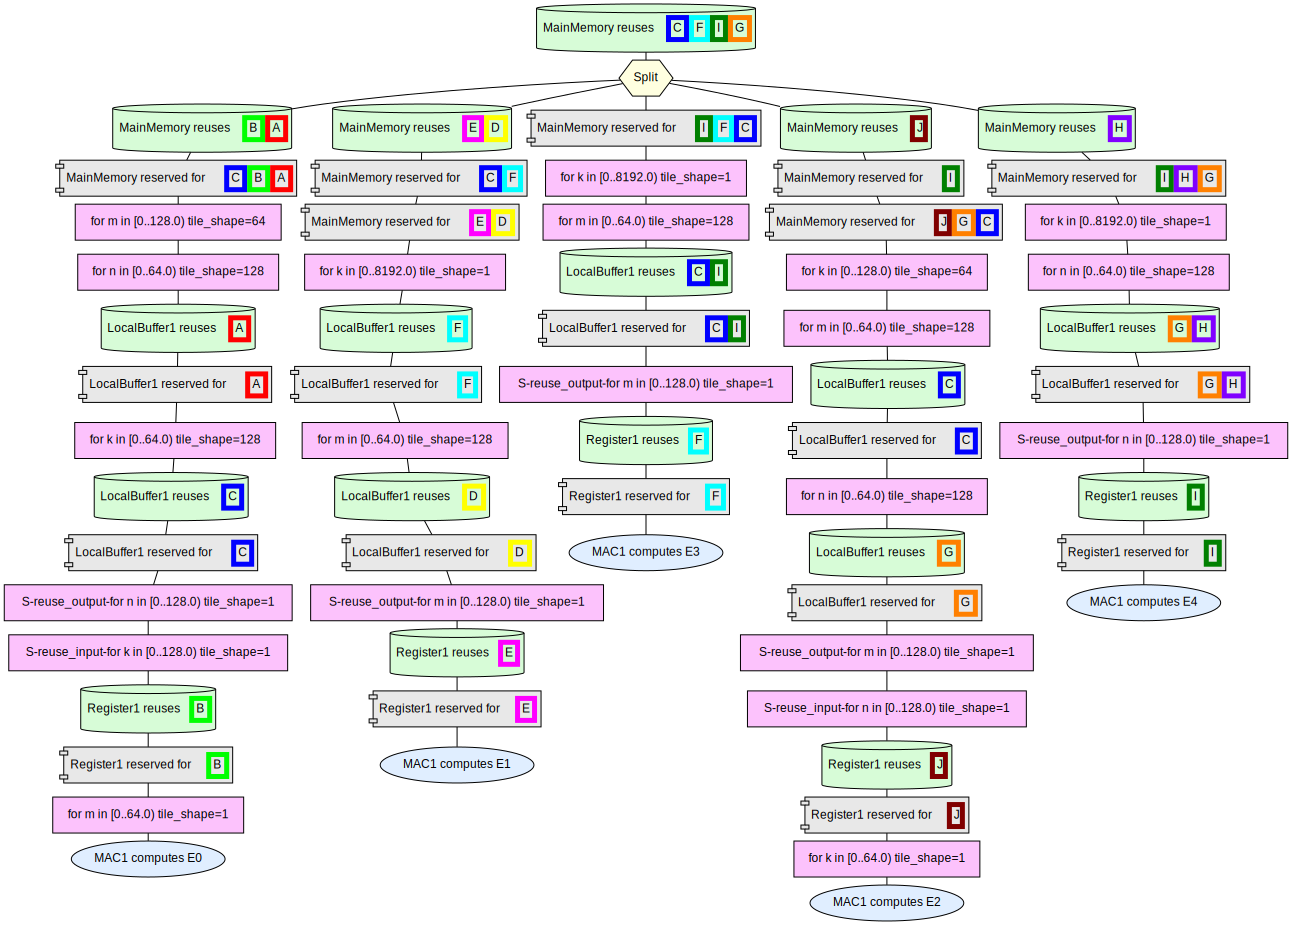

In [13]:
m2_full_mapping

In [14]:
m2_full_mapping.latency()

0.06541116948937997

In [15]:
latency

np.float32(0.06441253)